In [1]:
import numpy as np
import my_lib as lib
import matplotlib.pyplot as plt

g= 0.0005694263438424716 ± 1.90915490279579e-06 (1/nm)


<>:25: SyntaxWarning: invalid escape sequence '\ '
<>:25: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_11432/858768128.py:25: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(X, Y, label=f'$sin \ theta = {slope:.5f} \u00B1*{err:.5f} * Wavelength$')


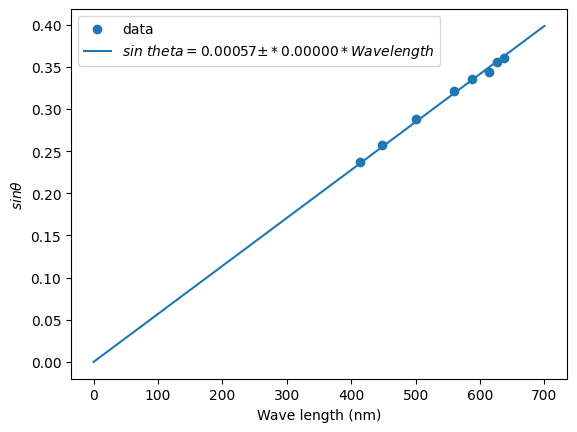

In [14]:
y= [0.3603676727,
0.3563495938,
0.3440807993,
0.3358249139,
0.3214853734,
0.2882577798,
0.2567474213,
0.2377341613]

x= [637,
627,
614,
588,
560,
501,
448,
413]

slope, err= lib.least_squares_zero_intercept(x , y)
print(f'g= {slope} \u00B1 {err} (1/nm)')
X=np.linspace(0, 700, 10000)
Y= slope*X

plt.scatter(x, y, label='data')
plt.plot(X, Y, label=f'$sin \ theta = {slope:.5f} \u00B1*{err:.5f} * Wavelength$')
plt.xlabel('Wave length (nm)')
plt.ylabel(r'$sin \theta $')
plt.legend()

In [37]:
#rydberg constant
L= [679.2277969,
506.145386,
447.2044654] #nm
L_inverse= 1/np.array(L) #nm^-1

n=2
m=np.array([3,4,5])
X= 1/n**2 - 1/m**2

slope, err= lib.least_squares_zero_intercept(X, L_inverse)
slope_meter= slope*1e9
print(f'Rydberg constant= {slope*1e9} \u00B1 {err*1e9} (m^(-1))')
percent_err=(slope_meter - 10973731.6)/10973731.6*100
print(f'percentage error= {percent_err}')

Rydberg constant= 10599186.144207822 ± 34972.747466761044 (m^(-1))
percentage error= -3.4131093181846865


metal emmission

In [41]:
# calibration

L_obs=[6870,
6200,
6150,
6110,
5940,
5770,
5460,
4950,
4910,
4370,
4090,
4060]

L_giv=[6910,
6230,
6200,
6150,
5960,
5790,
5460,
4940,
4890,
4350,
4070,
4030]

m, c,  m_err = lib.least_squares_normal(L_obs, L_giv)
print(r'lambda_giv=', slope, r'* lambda_obs ', c)
print(m)
print(c)

lambda_giv= 0.010599186144207823 * lambda_obs  -146.96215125184426
1.0287229626236456
-146.96215125184426


In [48]:
# copper
L_obs= np.array([6670, 6540, 6360, 5880, 5780, 5690, 5300, 5220, 5150, 5100, 4810, 4730, 4710, 4650, 4590, 4540, 4520, 4490, 4420, 4490, 4290, 4260, 4190, 4080])
L_corr= m* L_obs + c
L_lit= np.array( [
    4062.64,
    4651.12,
    4909.734,
    4931.698,
    4953.724,
    5051.793,
    5105.54,
    5153.24,
    5218.20,
    5292.52,
    5700.24,
    5782.13,
    6000.120,
    6150.384,
    6154.222,
    6216.939,
    6219.844,
    6273.349,
    6301.009,
    6377.840,
    6423.884,
    6448.559,
    6470.168,
    6481.437,
    6624.292,
    6641.396
])
L_corr


array([6714.62000945, 6580.88602431, 6395.71589103, 5901.92886898,
       5799.05657271, 5706.47150608, 5305.26955065, 5222.97171364,
       5150.96110626, 5099.52495813, 4801.19529897, 4718.89746196,
       4698.32300271, 4636.59962495, 4574.87624719, 4523.44009906,
       4502.86563981, 4472.00395093, 4399.99334354, 4472.00395093,
       4266.2593584 , 4235.39766952, 4163.38706214, 4050.22753625])

In [ ]:
# brass
L_obs= np.array([6370, 6890, 5770, 5690, 5300, 5220, 5150, 5100, 4810, 4730, 4680, 4650, 4590, 4540, 4510, 4490, 4400, 4270,4060])
L_corr= m*L_obs + c



In [51]:
#iodine vapor
L_obs= np.array([6200, 6170, 6130, 6090, 6050, 6010, 5980, 5930, 5890, 5860, 5810, 5780, 5750, 5730, 5690, 5660, 5630, 5600, 5570, 5540])
L_corr= m*L_obs + c

wavenumber=1/L_corr *1e7 #cm-1
wavenumber

array([1604.84786872, 1612.83597363, 1623.61130647, 1634.53158738,
       1645.59976089, 1656.81885183, 1665.33407599, 1679.72230348,
       1691.41314073, 1700.28862458, 1715.28991511, 1724.41842472,
       1733.64461524, 1739.85045311, 1752.39637828, 1761.92520664,
       1771.55822947, 1781.29716514, 1791.14377005, 1801.09983963])